# Etapa 1: Preprocesamiento y Detección de Data Leakage
**Archivo:** `notebooks/1_model_leakage_demo.ipynb`  
**Proyecto:** Heart Disease MLOps — Dr. Lihki Rubio  

### Objetivos
- Explorar el dataset Heart Failure Prediction
- Demostrar el impacto del *data leakage* en la evaluación del modelo
- Implementar **todos los modelos vistos en clase** con `Pipeline` + `GridSearchCV`
- Comparar AUC y Accuracy en un ranking final


## 1. Importación de librerías

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

# Modelos vistos en clase
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.svm           import SVC
from sklearn.naive_bayes   import GaussianNB
from sklearn.neighbors     import KNeighborsClassifier
from xgboost               import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")

## 2. Carga del Dataset
Descarga `heart.csv` desde [Kaggle - Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)  
y colócalo en la raíz del proyecto: `heart-disease-mlops/heart.csv`


In [29]:
df = pd.read_csv("../data/heart.csv")
print(f"Forma del dataset: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
df.head()

Forma del dataset: (918, 12)

Columnas: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Información general y valores nulos

In [30]:
print("=== Tipos de datos ===")
print(df.dtypes)
print()
print("=== Valores nulos ===")
print(df.isnull().sum())
print()
df.describe()


=== Tipos de datos ===
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

=== Valores nulos ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64



,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### 3.2 Distribución de la variable objetivo `HeartDisease`

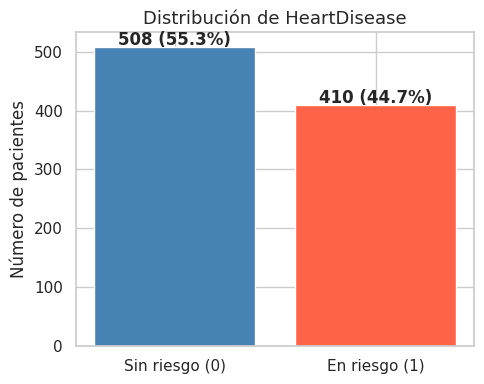

In [31]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["HeartDisease"].value_counts()
bars = ax.bar(["Sin riesgo (0)", "En riesgo (1)"], counts.values,
              color=["steelblue", "tomato"], edgecolor="white")
ax.set_title("Distribución de HeartDisease", fontsize=13)
ax.set_ylabel("Número de pacientes")
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 3,
            f"{v} ({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


### 3.3 Variables numéricas por clase

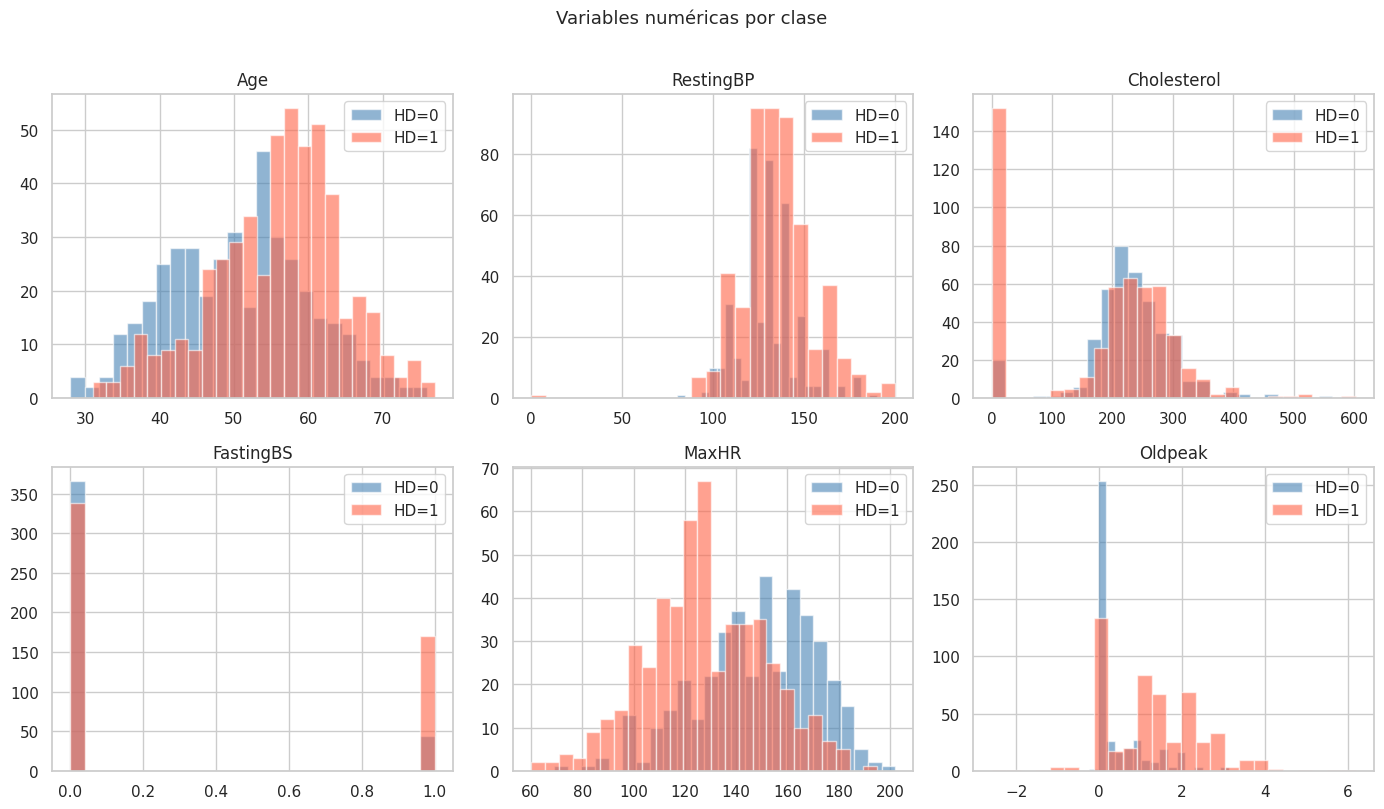

In [32]:
num_cols = df.select_dtypes(include=np.number).columns.drop("HeartDisease").tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols[:6]):
    for label, color in [(0, "steelblue"), (1, "tomato")]:
        axes[i].hist(df[df["HeartDisease"] == label][col], bins=25,
                     alpha=0.6, label=f"HD={label}", color=color)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle("Variables numéricas por clase", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 3.4 Variables categóricas vs HeartDisease

Variables categóricas: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


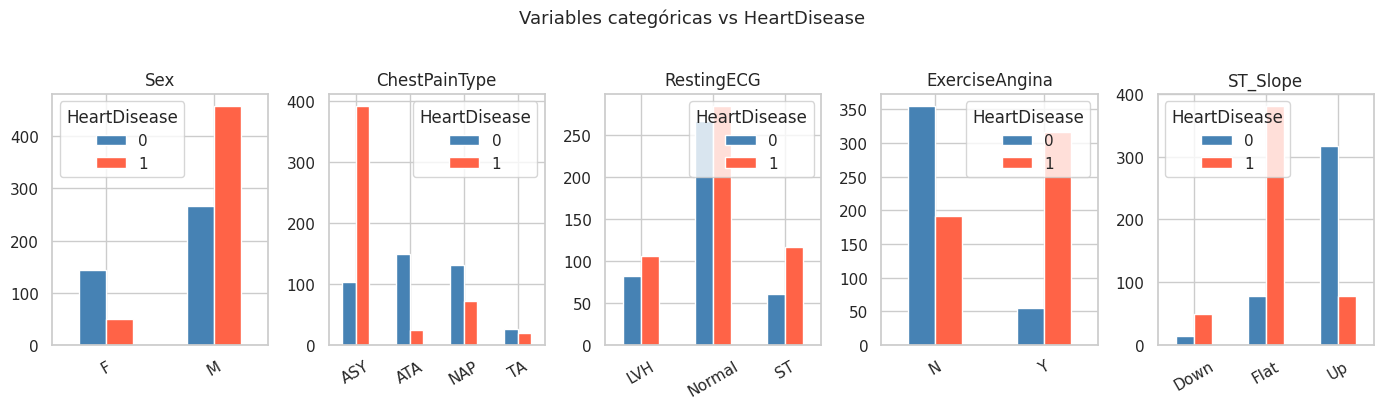

In [33]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Variables categóricas:", cat_cols)

fig, axes = plt.subplots(1, len(cat_cols), figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    ct = df.groupby([col, "HeartDisease"]).size().unstack(fill_value=0)
    ct.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Variables categóricas vs HeartDisease", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 3.5 Mapa de correlación

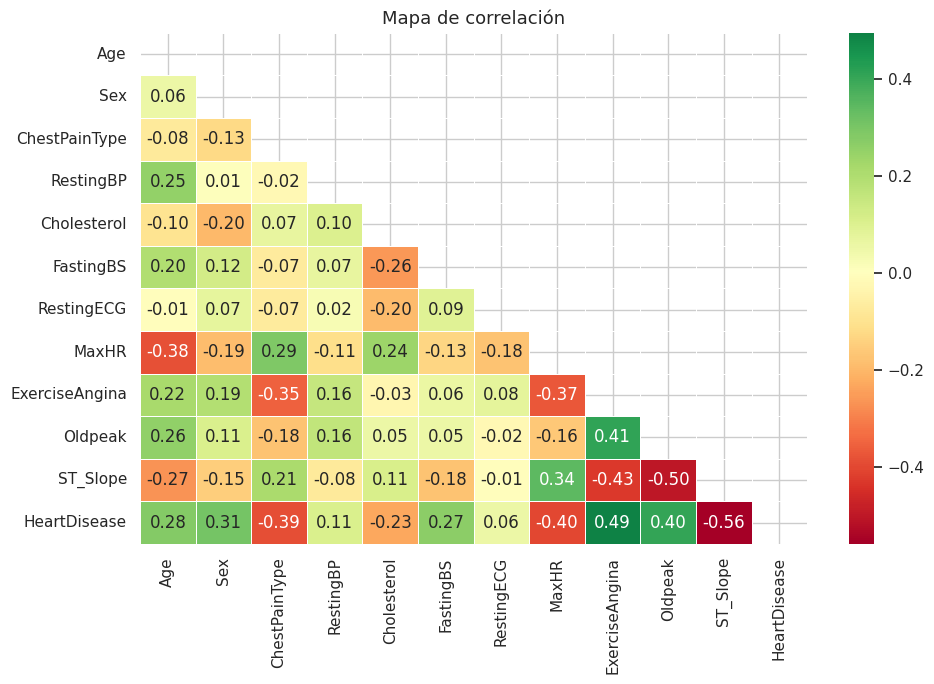

In [34]:
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(df_enc.corr(), dtype=bool))
sns.heatmap(df_enc.corr(), annot=True, fmt=".2f", mask=mask,
            cmap="RdYlGn", center=0, ax=ax, linewidths=0.5)
ax.set_title("Mapa de correlación", fontsize=13)
plt.tight_layout()
plt.show()


## 4. Preprocesamiento

In [35]:
# One-Hot Encoding para variables categóricas
df_clean = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_clean.drop("HeartDisease", axis=1)
y = df_clean["HeartDisease"]

print(f"Features tras encoding: {X.shape[1]}")
print(f"Ejemplos totales:       {X.shape[0]}")
print("\nColumnas finales:")
print(X.columns.tolist())


Features tras encoding: 15
Ejemplos totales:       918

Columnas finales:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


## 5. División del Dataset
La división **siempre se realiza ANTES** de cualquier transformación para evitar data leakage.


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras ({y_train.mean()*100:.1f}% positivos)")
print(f"Test:  {X_test.shape[0]} muestras  ({y_test.mean()*100:.1f}% positivos)")


Train: 734 muestras (55.3% positivos)
Test:  184 muestras  (55.4% positivos)


## 6. Demostración de Data Leakage
**Data Leakage** ocurre cuando información del conjunto de prueba contamina el entrenamiento, produciendo métricas irrealmente altas que no se replican en producción.

### Tipos de leakage demostrados:
- **Leakage por feature artificial**: variable derivada directamente del target
- **Leakage por escalado prematuro**: `fit_transform` en todo el dataset antes de dividir


### 6.1 Flujo INCORRECTO — con data leakage

In [37]:
# Feature que "filtra" la etiqueta (altamente correlacionada)
np.random.seed(42)
X_leaky = X.copy()
X_leaky["leaky_feature"] = y + np.random.normal(0, 0.01, size=len(y))

# ❌ MAL: escalar ANTES de dividir → el scaler aprende estadísticas del test
scaler_bad = MinMaxScaler()
X_leaky_scaled = scaler_bad.fit_transform(X_leaky)  # ve todo el dataset

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leaky_scaled, y, test_size=0.2, random_state=42, stratify=y
)

svc_bad = SVC(probability=True, C=1, gamma=0.1)
svc_bad.fit(X_train_l, y_train_l)
auc_leaky = roc_auc_score(y_test_l, svc_bad.predict_proba(X_test_l)[:, 1])
acc_leaky = accuracy_score(y_test_l, svc_bad.predict(X_test_l))

print(f"AUC  con leakage: {auc_leaky:.4f}")
print(f"Acc  con leakage: {acc_leaky:.4f}")

AUC  con leakage: 1.0000
Acc  con leakage: 1.0000


### 6.2 Flujo CORRECTO — Pipeline evita leakage

In [38]:
# Pipeline encapsula scaler + modelo
# El scaler solo aprende de X_train en cada fold de CV
pipe_correct = Pipeline([
    ("scaler", MinMaxScaler()),
    ("svc",    SVC(probability=True))
])
param_grid = {"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1]}
grid_correct = GridSearchCV(pipe_correct, param_grid, cv=5,
                             scoring="roc_auc", n_jobs=-1)
grid_correct.fit(X_train, y_train)

auc_clean = roc_auc_score(y_test, grid_correct.predict_proba(X_test)[:, 1])
acc_clean = accuracy_score(y_test, grid_correct.predict(X_test))

print(f"AUC  sin leakage: {auc_clean:.4f}")
print(f"Acc  sin leakage: {acc_clean:.4f}")


AUC  sin leakage: 0.9311
Acc  sin leakage: 0.8641


### 6.3 Comparación visual del impacto

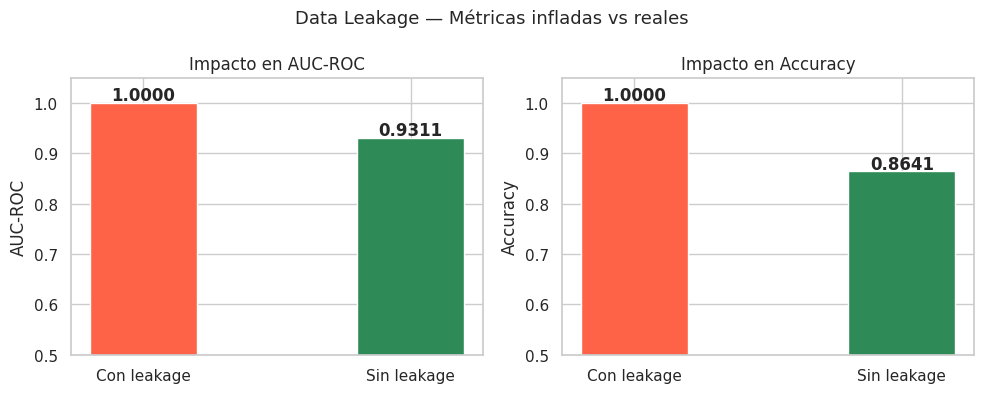

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric, vals, title in zip(
    axes,
    ["AUC-ROC", "Accuracy"],
    [[auc_leaky, auc_clean], [acc_leaky, acc_clean]],
    ["Impacto en AUC-ROC", "Impacto en Accuracy"]
):
    bars = ax.bar(["Con leakage", "Sin leakage"], vals,
                  color=["tomato", "seagreen"], edgecolor="white", width=0.4)
    ax.set_ylim(0.5, 1.05)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f"{v:.4f}", ha="center", fontweight="bold")

plt.suptitle("Data Leakage — Métricas infladas vs reales", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Función reutilizable `train_pipeline`

In [40]:
def train_pipeline(X_train, y_train, model, param_grid, cv=5):
    """
    Entrena un Pipeline(scaler → modelo) con GridSearchCV.

    Parámetros
    ----------
    X_train   : features de entrenamiento
    y_train   : etiquetas de entrenamiento
    model     : instancia del clasificador sklearn
    param_grid: dict con hiperparámetros (prefijo 'clf__')
    cv        : número de folds de validación cruzada

    Retorna
    -------
    grid      : GridSearchCV ajustado (accede a .best_estimator_)
    """
    pipe = Pipeline([
        ("scaler", MinMaxScaler()),
        ("clf",    model)
    ])
    grid = GridSearchCV(
        pipe, param_grid,
        cv=cv, scoring="roc_auc",
        n_jobs=-1, verbose=0
    )
    grid.fit(X_train, y_train)
    return grid


def evaluate_model(grid, X_test, y_test, model_name):
    """Evalúa un grid entrenado y retorna un dict con métricas."""
    y_pred  = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    return {
        "Modelo":       model_name,
        "AUC-ROC":      round(roc_auc_score(y_test, y_proba), 4),
        "Accuracy":     round(accuracy_score(y_test, y_pred), 4),
        "Best params":  grid.best_params_,
        "grid":         grid
    }

## 8. Entrenamiento de todos los modelos vistos en clase
Modelos: **LogisticRegression, RandomForest, SVC, GaussianNB, KNeighbors, XGBoost**  
Cada uno dentro de un `Pipeline` con `MinMaxScaler` y optimizado con `GridSearchCV`.


In [41]:
# Definición de modelos y sus grids de hiperparámetros
MODELS = {
    "LogisticRegression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {"clf__C": [0.01, 0.1, 1, 10],
         "clf__solver": ["lbfgs", "liblinear"]}
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {"clf__n_estimators": [100, 200],
         "clf__max_depth":    [None, 5, 10],
         "clf__min_samples_split": [2, 5]}
    ),
    "SVC": (
        SVC(probability=True, random_state=42),
        {"clf__C":     [0.1, 1, 10],
         "clf__gamma": [0.01, 0.1, "scale"]}
    ),
    "GaussianNB": (
        GaussianNB(),
        {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}
    ),
    "KNeighbors": (
        KNeighborsClassifier(),
        {"clf__n_neighbors": [3, 5, 7, 11],
         "clf__weights":     ["uniform", "distance"],
         "clf__metric":      ["euclidean", "manhattan"]}
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0),
        {"clf__n_estimators":  [100, 200],
         "clf__max_depth":     [3, 5, 7],
         "clf__learning_rate": [0.01, 0.1, 0.2]}
    ),
}

In [42]:
# Entrenar todos los modelos con train_pipeline()
results = []

for name, (model, param_grid) in MODELS.items():
    print(f"Entrenando {name}...", end=" ")
    grid = train_pipeline(X_train, y_train, model, param_grid)
    result = evaluate_model(grid, X_test, y_test, name)
    results.append(result)
    print(f"AUC={result['AUC-ROC']:.4f} | Acc={result['Accuracy']:.4f}")

Entrenando LogisticRegression... AUC=0.9314 | Acc=0.8967
Entrenando RandomForest... AUC=0.9363 | Acc=0.8804
Entrenando SVC... AUC=0.9311 | Acc=0.8641
Entrenando GaussianNB... AUC=0.9451 | Acc=0.9130
Entrenando KNeighbors... AUC=0.9431 | Acc=0.8913
Entrenando XGBoost... AUC=0.9365 | Acc=0.8967


## 9. Ranking comparativo de modelos

In [43]:
# Tabla de resultados ordenada por AUC
ranking = pd.DataFrame([{k: v for k, v in r.items() if k != "grid"} for r in results])
ranking = ranking.sort_values("AUC-ROC", ascending=False).reset_index(drop=True)
ranking.index += 1  # empezar en 1
ranking.index.name = "Rank"

print("=== RANKING DE MODELOS ===")
print(ranking[["Modelo", "AUC-ROC", "Accuracy"]].to_string())


=== RANKING DE MODELOS ===
                  Modelo  AUC-ROC  Accuracy
Rank                                       
1             GaussianNB   0.9451    0.9130
2             KNeighbors   0.9431    0.8913
3                XGBoost   0.9365    0.8967
4           RandomForest   0.9363    0.8804
5     LogisticRegression   0.9314    0.8967
6                    SVC   0.9311    0.8641


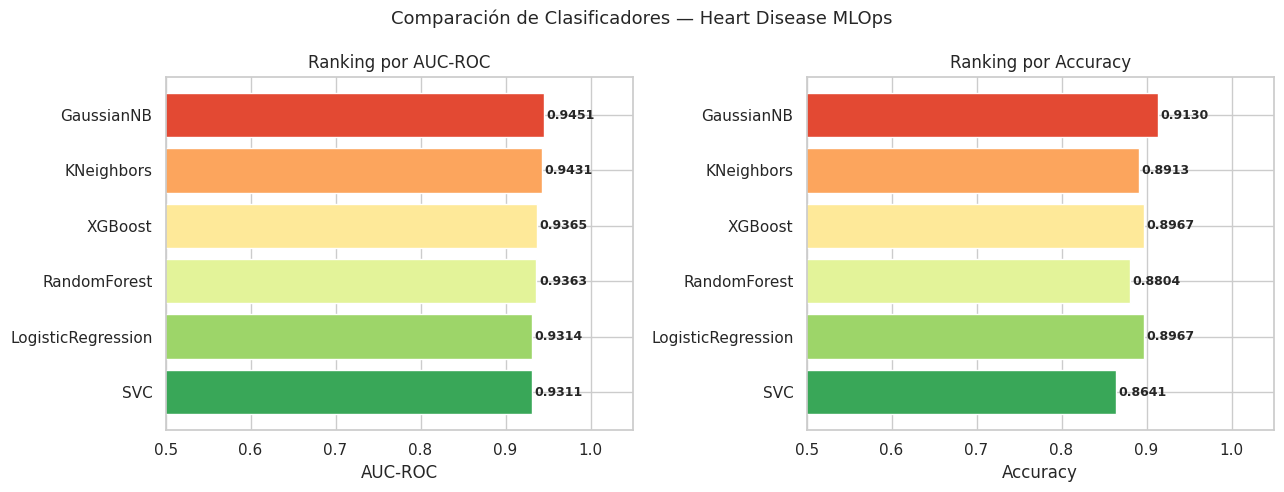

In [44]:
# Visualización del ranking
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = sns.color_palette("RdYlGn", len(ranking))

for ax, metric in zip(axes, ["AUC-ROC", "Accuracy"]):
    vals   = ranking[metric].values
    models = ranking["Modelo"].values
    colors = palette[::-1]

    bars = ax.barh(models[::-1], vals[::-1], color=colors, edgecolor="white")
    ax.set_xlim(0.5, 1.05)
    ax.set_title(f"Ranking por {metric}", fontsize=12)
    ax.set_xlabel(metric)
    for bar, v in zip(bars, vals[::-1]):
        ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
                f"{v:.4f}", va="center", fontsize=9, fontweight="bold")

plt.suptitle("Comparación de Clasificadores — Heart Disease MLOps", fontsize=13)
plt.tight_layout()
plt.show()


## 10. Curvas ROC de todos los modelos

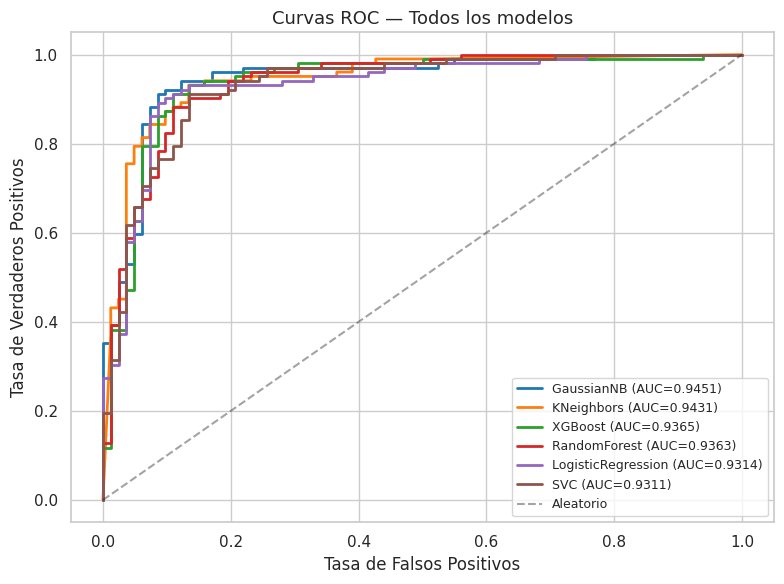

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10.colors

for i, r in enumerate(sorted(results, key=lambda x: x["AUC-ROC"], reverse=True)):
    y_proba = r["grid"].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, color=colors[i],
            label=f"{r['Modelo']} (AUC={r['AUC-ROC']:.4f})", lw=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curvas ROC — Todos los modelos", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


## 11. Evaluación detallada del mejor modelo

   Mejor modelo: GaussianNB
   AUC-ROC:  0.9451
   Accuracy: 0.913
   Params:   {'clf__var_smoothing': 1e-09}


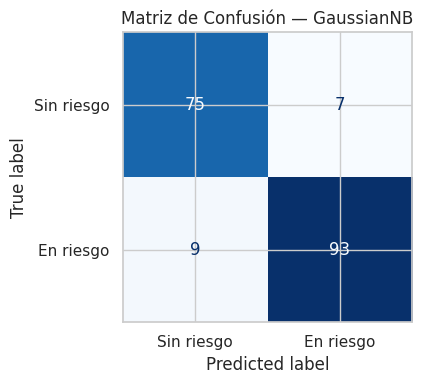

In [46]:
best = sorted(results, key=lambda x: x["AUC-ROC"], reverse=True)[0]
print(f"   Mejor modelo: {best['Modelo']}")
print(f"   AUC-ROC:  {best['AUC-ROC']}")
print(f"   Accuracy: {best['Accuracy']}")
print(f"   Params:   {best['Best params']}")

# Matriz de confusión
y_pred_best = best["grid"].predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Sin riesgo", "En riesgo"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Matriz de Confusión — {best['Modelo']}")
plt.tight_layout()
plt.show()


## 12. Exportar el mejor modelo

In [47]:
import joblib

joblib.dump(best["grid"].best_estimator_, "../model.joblib")
print(f"Modelo guardado en ../model.joblib")
print(f"Modelo exportado: {best['Modelo']}")


Modelo guardado en ../model.joblib
Modelo exportado: GaussianNB


## 13. Conclusiones

1. **Sin valores nulos** — el dataset está limpio.
2. **Data leakage verificado** — escalar antes de dividir infla el AUC artificialmente.
3. **`Pipeline` es la solución** — garantiza que el scaler sólo aprende de train en cada fold.
4. **Función `train_pipeline`** — encapsula el flujo, facilitando comparar múltiples modelos.
5. **Ranking completado** — se compararon 6 clasificadores (LR, RF, SVC, GNB, KNN, XGB).
6. **Modelo exportado** — el mejor estimador queda guardado en `model.joblib` para la Etapa 3.
